<table class="table table-bordered">
    <tr>
        <th style="width:250px"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 100%; height: 125px; "></th>
        <th style="text-align:center;"><h1>Data Wrangling</h1><h2>Assignment 1 </h2><h3>Diploma in Data Science</h3></th>
    </tr>
</table>

# Table Of Contents

## 1. [Steps](#part1)
   - [1.1 Step 0](#part1.1)
   - [1.2 Step 1](#part1.2)
   - [1.3 Step 2](#part1.3)
   - [1.4 Step 3](#part1.4)
   - [1.5 Step 4](#part1.5)
   - [1.6 Step 5](#part1.6)
   - [1.7 Step 6](#part1.7)
   - [1.8 Step 7](#part1.8)
   - [1.9 Step 8](#part1.9)
   
   
## 2. [Report](#part2)
   - [2.1 Introduction](#part2.1)
   - [2.2 Data Exploration](#part2.2)
   - [2.3 Data Cleansing ](#part2.3)
   - [2.4 Data Transformation ](#part2.4)
   - [2.5  Feature Engineering](#part2.5)
   - [2.6  Linear Regression Model](#part2.6)
   - [2.7 Summary and Further Improvements ](#part2.7)


# 1. Steps <a id="part1"></a>

## 1.1 Step 0 <a id="part1.1"></a>

In [1]:
from IPython.display import Image

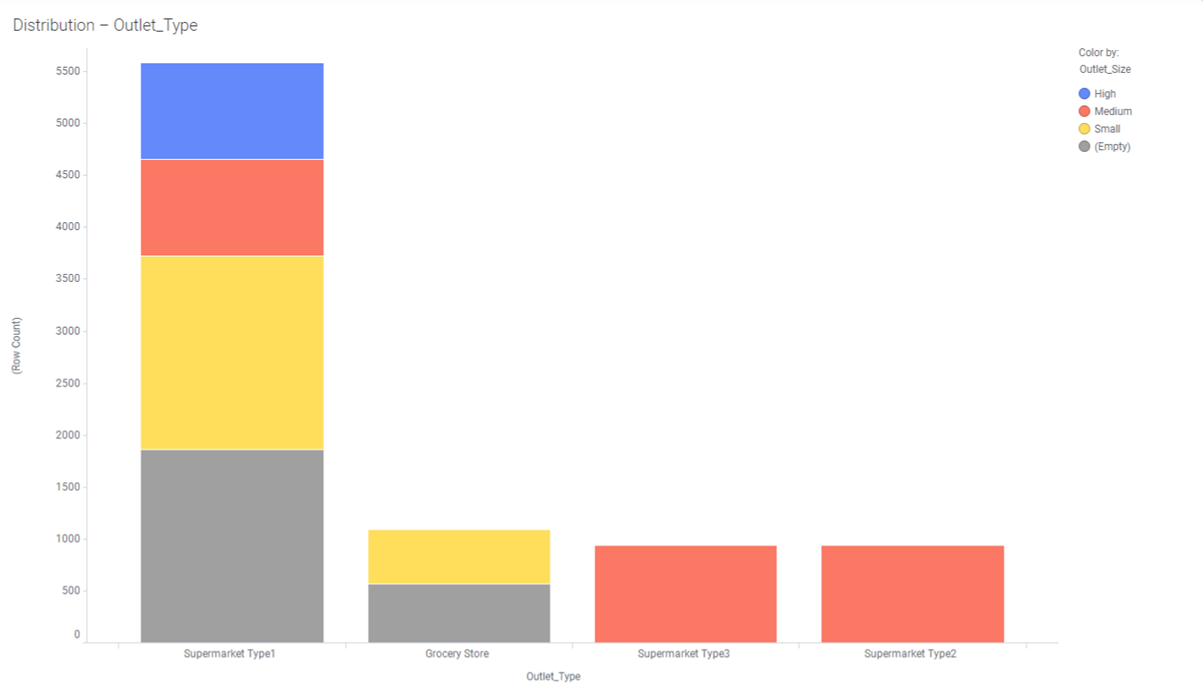

In [2]:
Image(filename="./outlet size by outlet type.png")

This visual shows the breakdown of the outlet size for each outlet type from this visual, it shows that there are 4 different outlet types supermarket type1, supermarket type3, supermarket type3, and grocery store, and supermarket type1 has the most number of outlets and supermarket type2 has the least. It also shows that this data set contains null values and supermarket type1 has all all 3 tiers of outlet sizes as well as null values, grocery store has small outlet size and null values. Both supermarket type 3 and 2 have only medium outlet size.

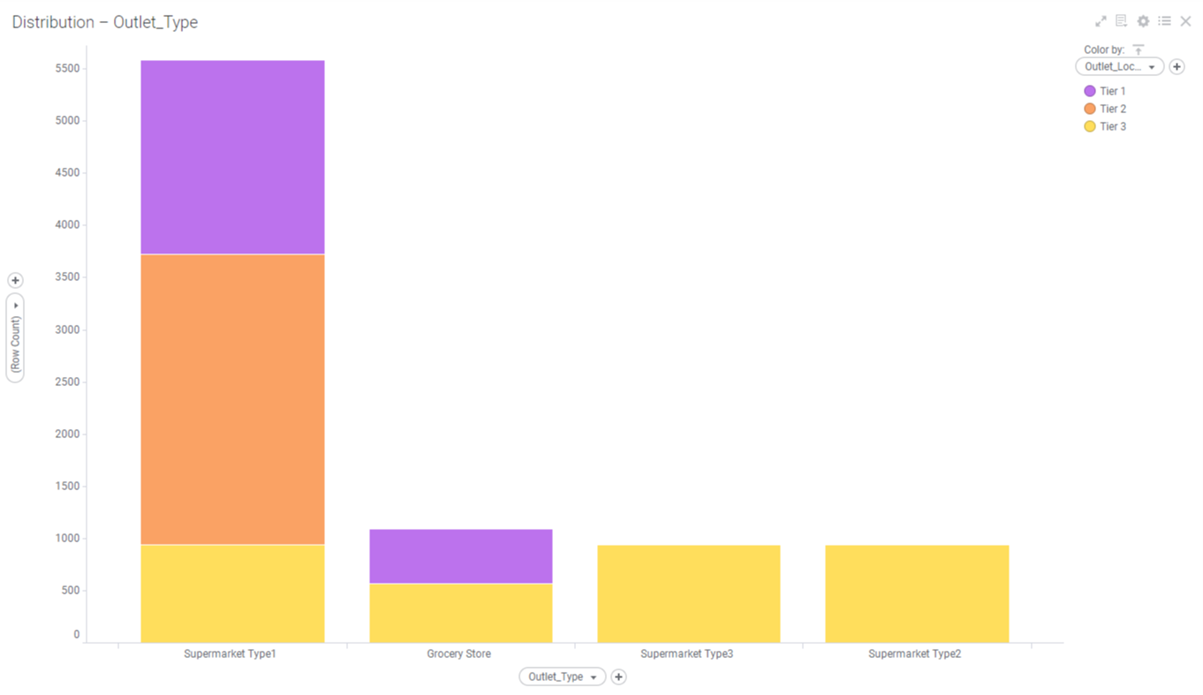

In [3]:
Image(filename="./outlet location by outlet type.png")

This visual shows the breakdown of the outlet locations tier for each outlet type. from this visual, it shows that for the 4 different outlet types, Supermarket Type 1 has all 3 tiers of outlet location type while Grocery store has Tier 1 and 3 and Supermarket Type 3 and 2 only have tier 3 outlet location types with no null values.

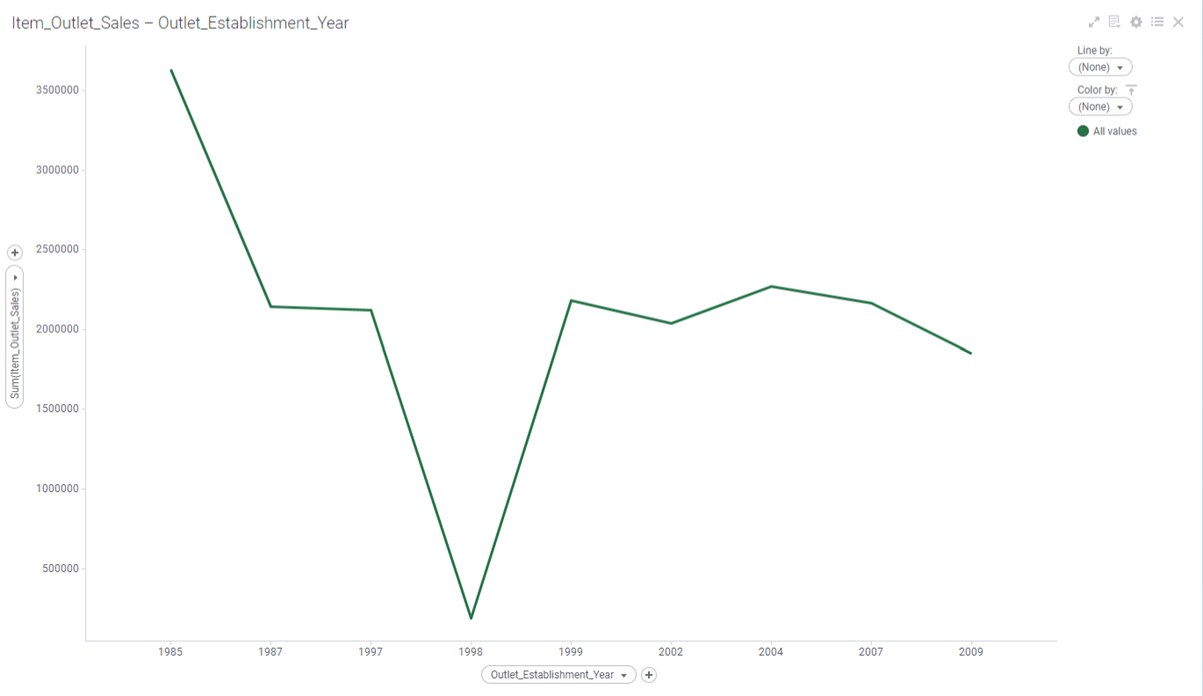

In [4]:
Image(filename="./item outlet sales by establishment year.png")

This visual shows the breakdown of item outlet sales by establishment year. This visual shows that the outlets that are established in the year 1985 has the highest sales and outlets that are established in the year 1998 has the lowest sales. while the other years do not show such drastic changes. With this data, we can look at why outlets established in the year 1998 received such bad sales and see how we can prevent that from occurring again and what was done for outlets established in the year 1995 to have such a drastic height in sales.

In [5]:
# import the pacakges
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import scipy.stats as stats
from feature_engine.outliers import Winsorizer

In [7]:
from feature_engine.transformation import YeoJohnsonTransformer

In [8]:
from sklearn.model_selection import train_test_split

## 1.2 Step 1: Load Data into Jupyter Notebook <a id="part1.2"></a>

In [9]:
supermarket_data = pd.read_csv('./supermarket.csv')

In [10]:
supermarket_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [11]:
supermarket_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [12]:
supermarket_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [13]:
supermarket_data.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [14]:
supermarket_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [15]:
supermarket_data.isnull().mean()

Item_Identifier              0.000000
Item_Weight                  0.171653
Item_Fat_Content             0.000000
Item_Visibility              0.000000
Item_Type                    0.000000
Item_MRP                     0.000000
Outlet_Identifier            0.000000
Outlet_Establishment_Year    0.000000
Outlet_Size                  0.282764
Outlet_Location_Type         0.000000
Outlet_Type                  0.000000
Item_Outlet_Sales            0.000000
dtype: float64

Text(0.5, 1.0, 'Quantifying missing data')

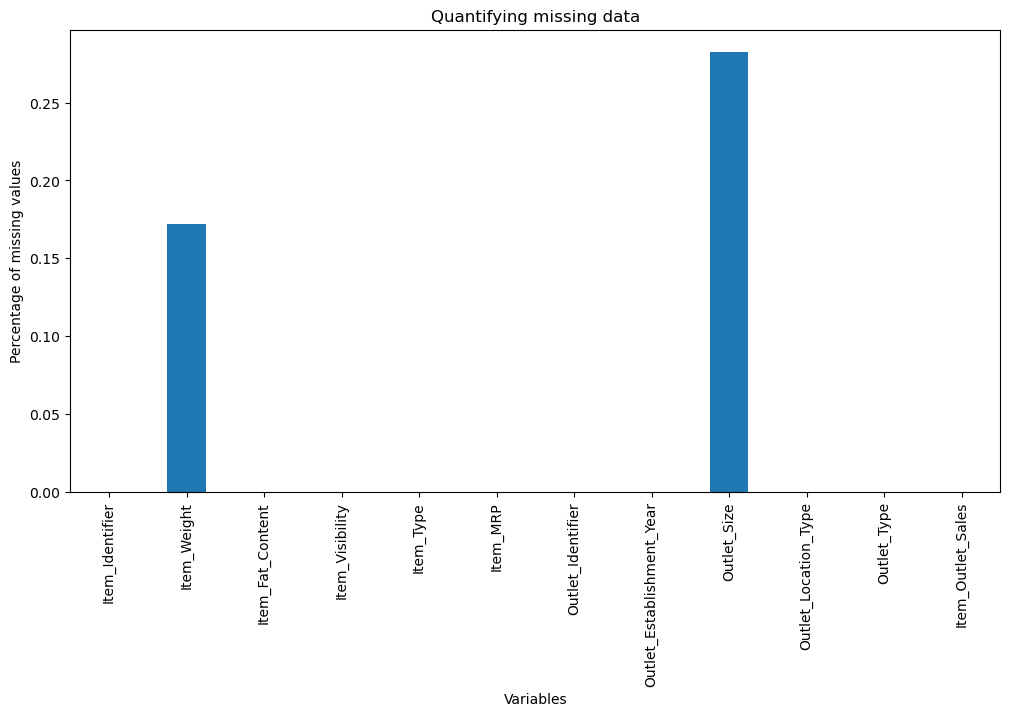

In [16]:
supermarket_data.isnull().mean().plot.bar(figsize=(12,6))
plt.ylabel('Percentage of missing values')
plt.xlabel('Variables')
plt.title('Quantifying missing data')

In [17]:
supermarket_data.nunique()

Item_Identifier              1559
Item_Weight                   415
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

In [18]:
supermarket_data = supermarket_data.replace("low fat", "Low Fat")
supermarket_data = supermarket_data.replace("LF", "Low Fat")

In [19]:
supermarket_data = supermarket_data.replace("reg", "Regular Fat")

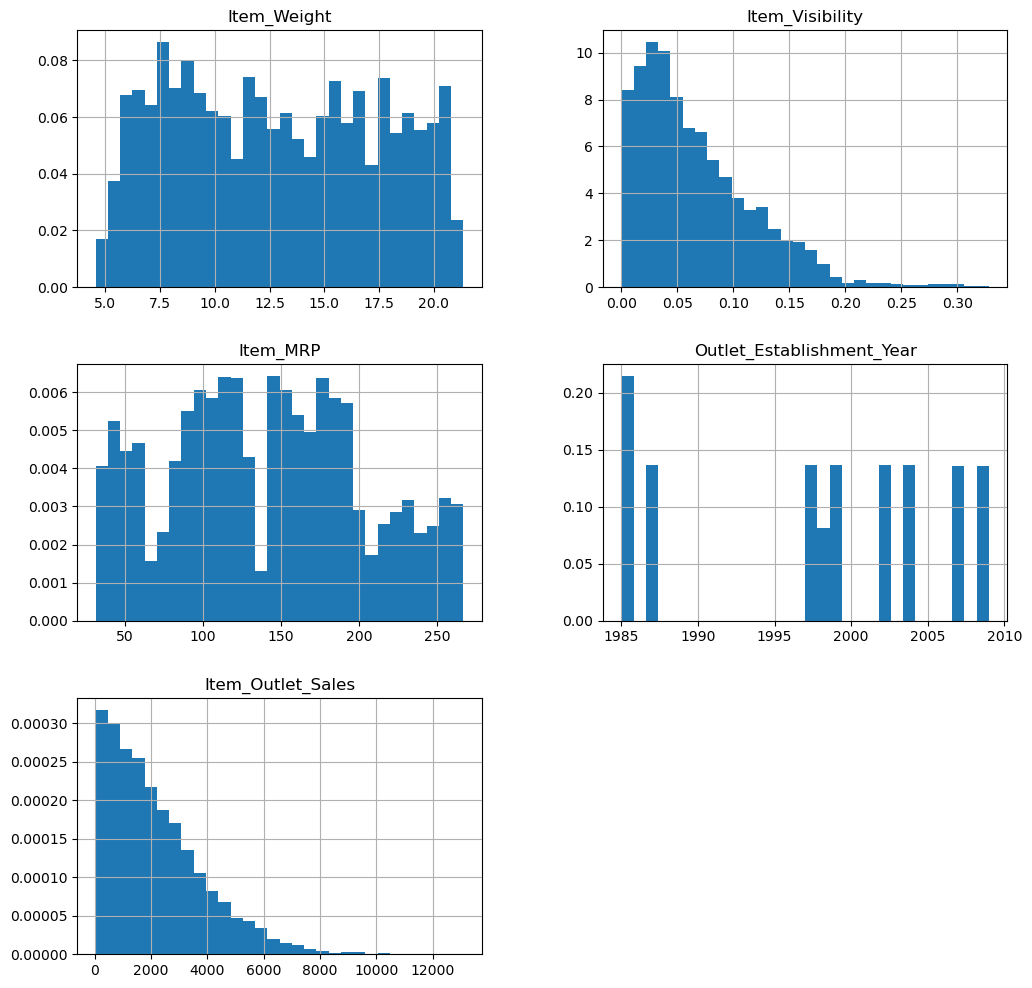

In [20]:
supermarket_data.hist(bins=30, figsize=(12,12), density=True)
plt.show()

## 1.3 Step 2: Data Preprocessing <a id="part1.3"></a>

In [21]:
def diagnostic_plots(df, variable):
    # function takes a dataframe (df) and
    # the variable of interest as arguments

    # define figure size
    plt.figure(figsize=(18, 8))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], kde=True)
    plt.title('Histogram')
    
    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Quantiles')

    # boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

In [22]:
def find_boundaries(df, variable, distance):

    # distance passed as an argument, gives us the option to
    # estimate 1.5 times or 3 times the IQR to calculate
    # the boundaries.

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
    upper_boundary = df[variable].quantile(0.75) + (IQR * distance)

    return upper_boundary, lower_boundary

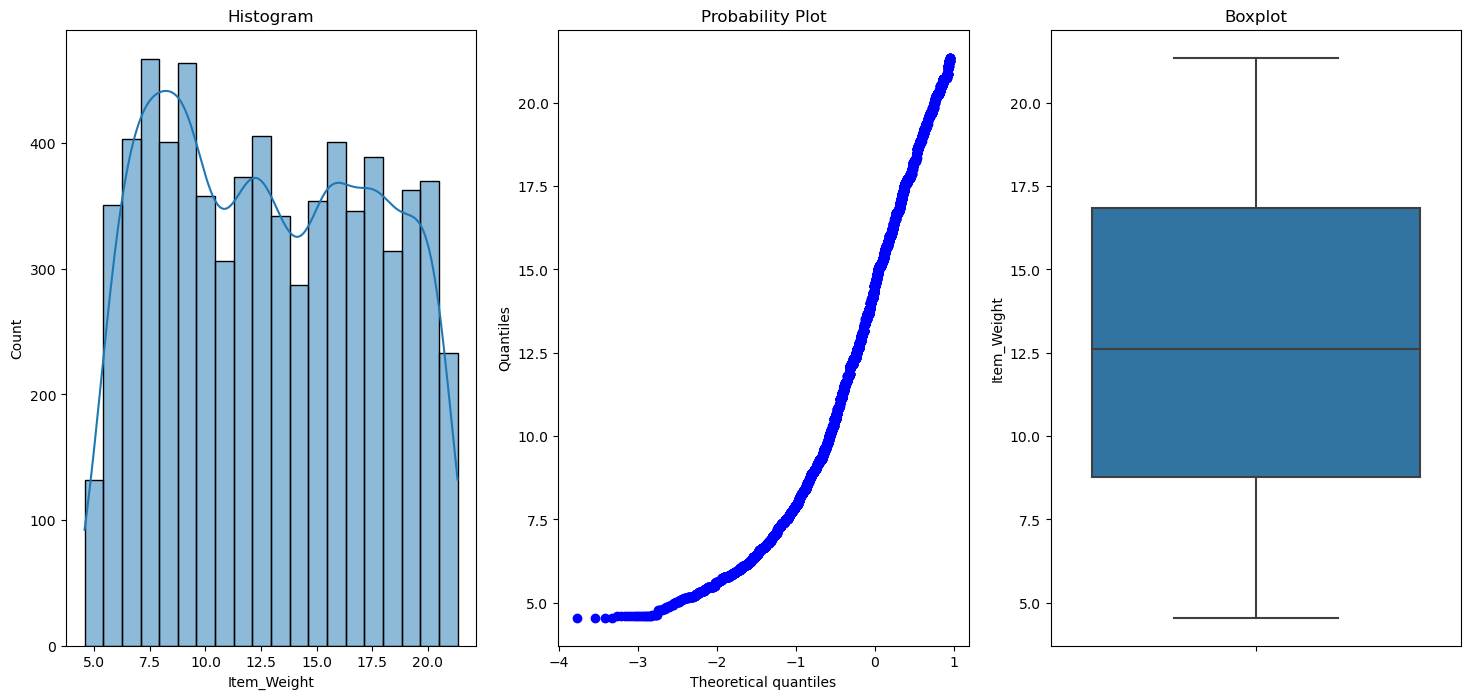

In [23]:
diagnostic_plots(supermarket_data,'Item_Weight')

In [24]:
upper_boundary, lower_boundary = find_boundaries(supermarket_data, 'Item_Weight',1.5) #1.5???
upper_boundary, lower_boundary

(28.964375000000004, -3.340625000000003)

In [25]:
outliers = np.where(supermarket_data['Item_Weight'] > upper_boundary, True,
                    np.where(supermarket_data['Item_Weight'] < lower_boundary, True, False))
outliers.sum()

0

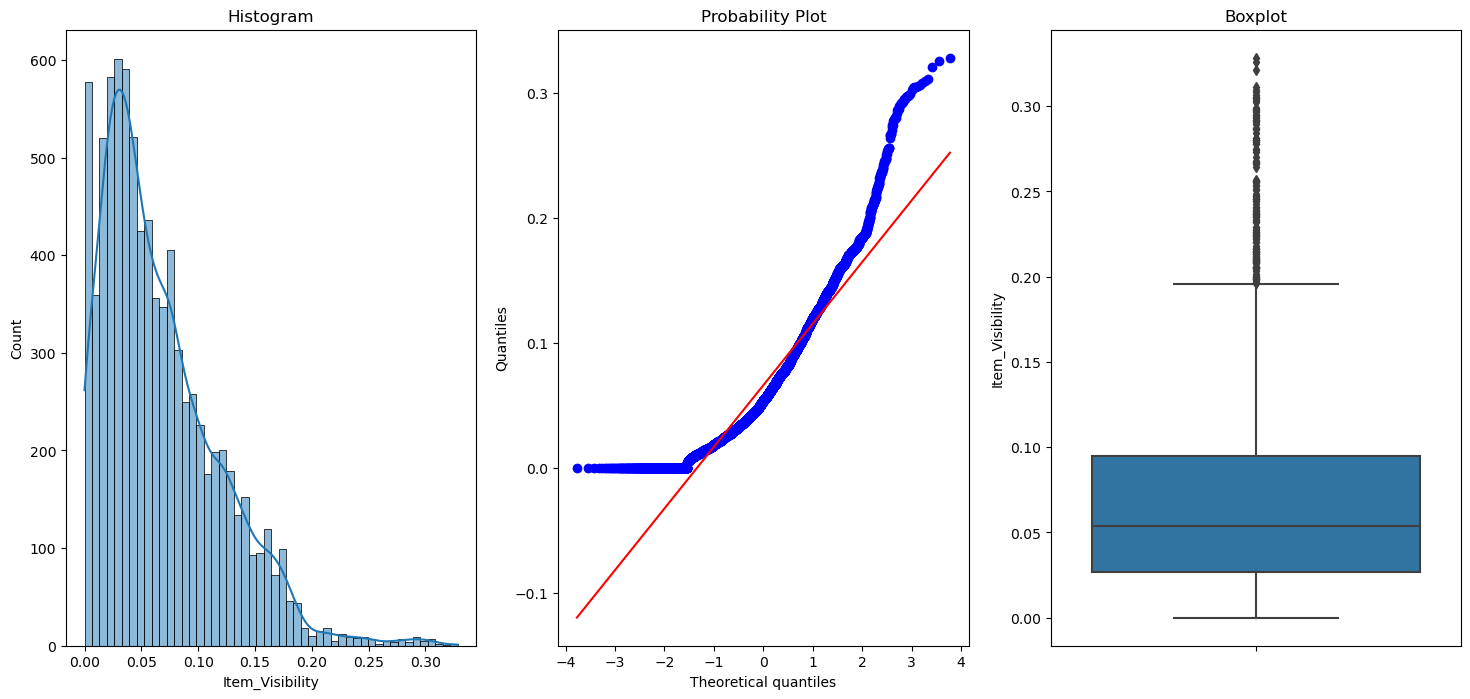

In [26]:
diagnostic_plots(supermarket_data,'Item_Visibility')

In [27]:
upper_boundary, lower_boundary = find_boundaries(supermarket_data, 'Item_Visibility',1.5) #1.5???
upper_boundary, lower_boundary

(0.195979015, -0.07440424500000001)

In [28]:
outliers = np.where(supermarket_data['Item_Visibility'] > upper_boundary, True,
                    np.where(supermarket_data['Item_Visibility'] < lower_boundary, True, False))
outliers.sum()

144

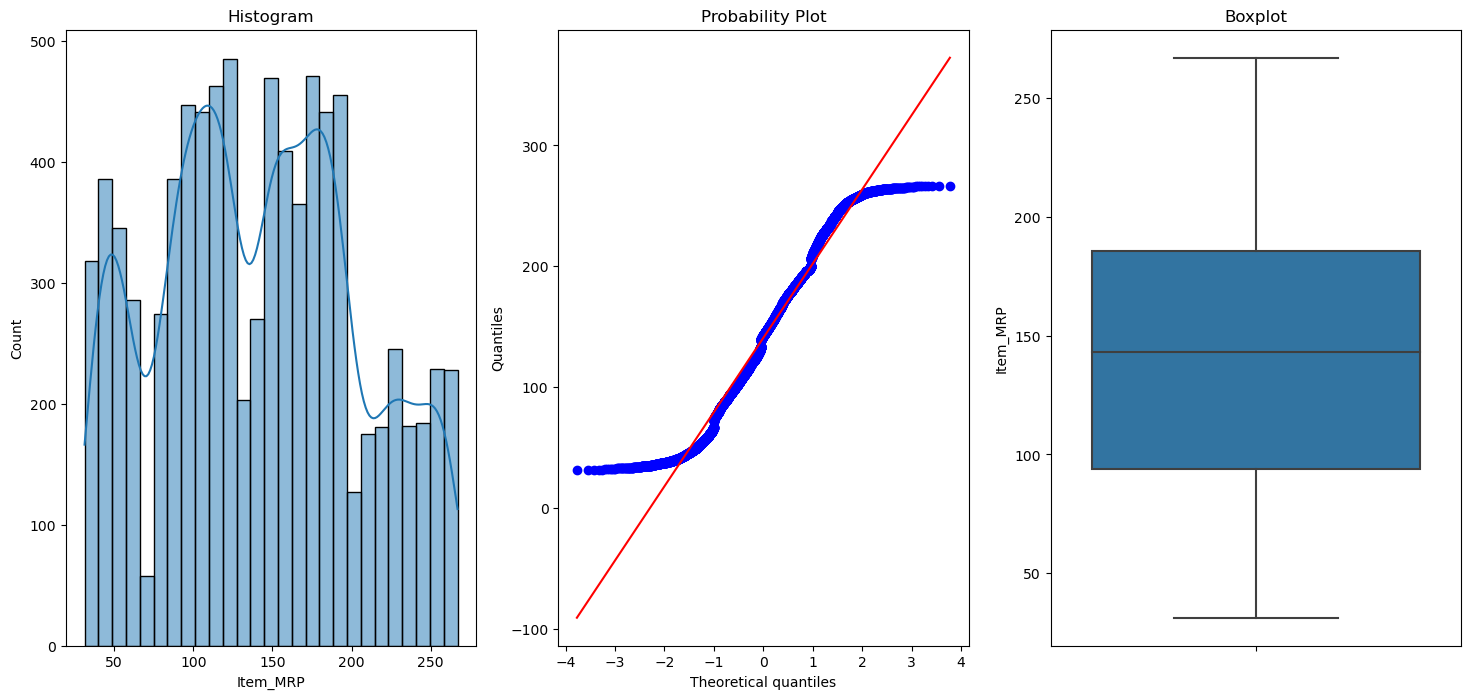

In [29]:
diagnostic_plots(supermarket_data,'Item_MRP')

In [30]:
upper_boundary, lower_boundary = find_boundaries(supermarket_data, 'Item_MRP',1.5) #1.5???
upper_boundary, lower_boundary

(323.3695, -43.8993)

In [31]:
outliers = np.where(supermarket_data['Item_MRP'] > upper_boundary, True,
                    np.where(supermarket_data['Item_MRP'] < lower_boundary, True, False))
outliers.sum()

0

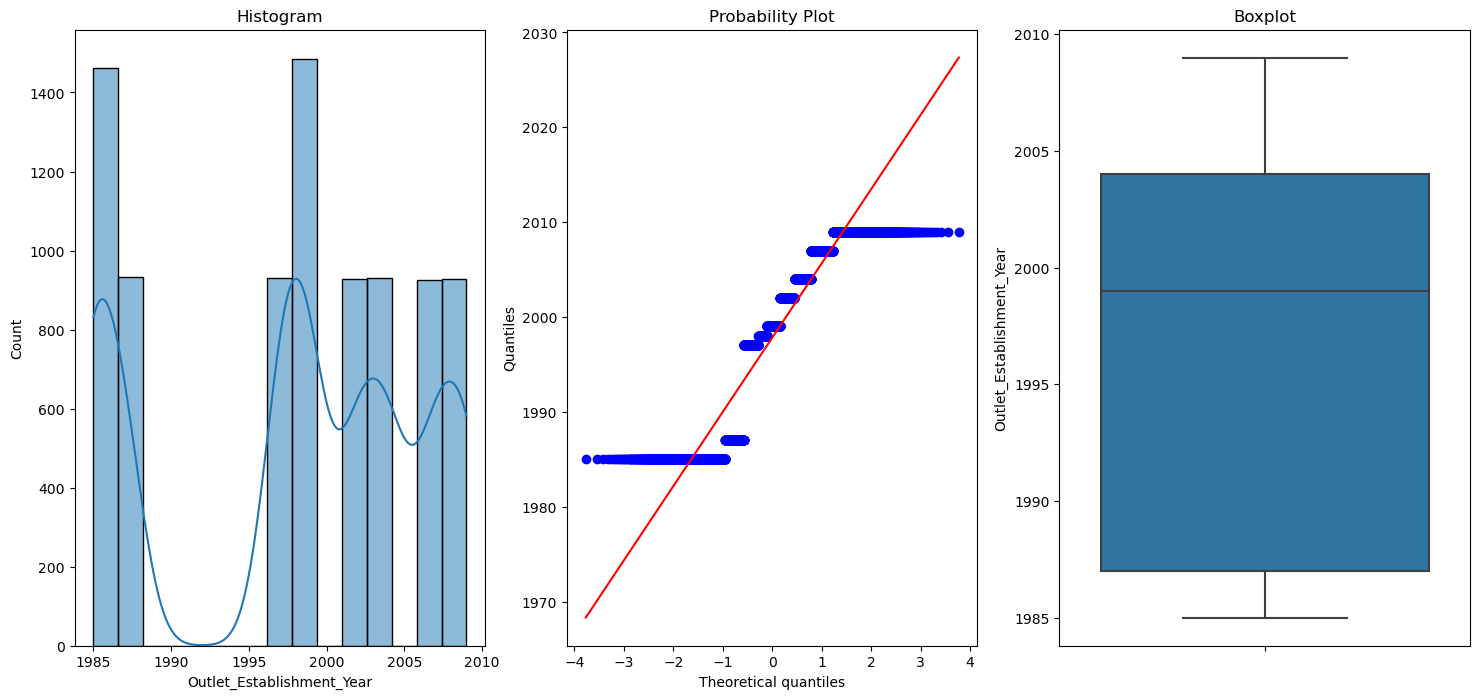

In [32]:
diagnostic_plots(supermarket_data,'Outlet_Establishment_Year')

In [33]:
upper_boundary, lower_boundary = find_boundaries(supermarket_data, 'Outlet_Establishment_Year',1.5) #1.5???
upper_boundary, lower_boundary

(2029.5, 1961.5)

In [34]:
outliers = np.where(supermarket_data['Outlet_Establishment_Year'] > upper_boundary, True,
                    np.where(supermarket_data['Outlet_Establishment_Year'] < lower_boundary, True, False))
outliers.sum()

0

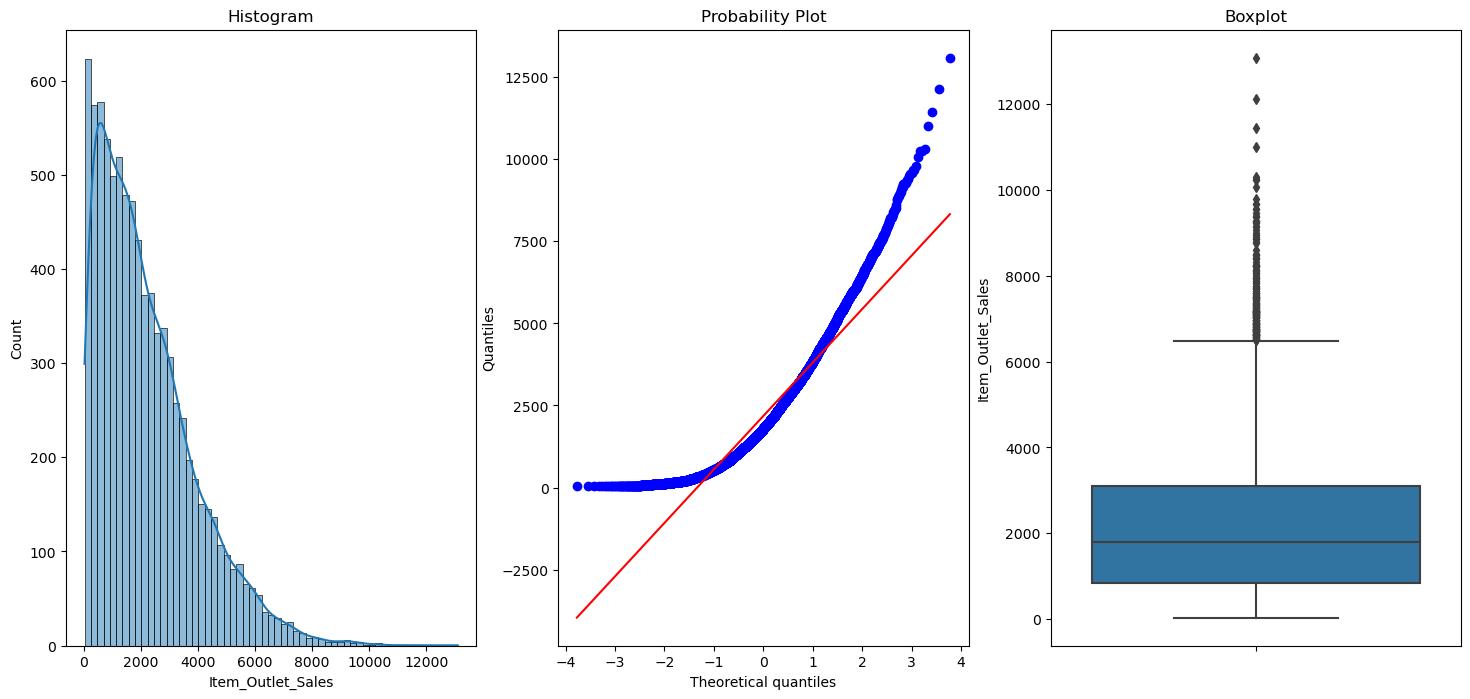

In [35]:
diagnostic_plots(supermarket_data,'Item_Outlet_Sales')

In [36]:
upper_boundary, lower_boundary = find_boundaries(supermarket_data, 'Item_Outlet_Sales',1.5) #1.5???
upper_boundary, lower_boundary

(6501.8699, -2566.3261)

In [37]:
outliers = np.where(supermarket_data['Item_Outlet_Sales'] > upper_boundary, True,
                    np.where(supermarket_data['Item_Outlet_Sales'] < lower_boundary, True, False))
outliers.sum()

186

### Winsorisation

In [38]:
windsorizer = Winsorizer(capping_method ='quantiles', 
                        tail='both', # cap left, right or both tails
                        fold =0.05,
                        variables=['Item_Visibility'])#, 'Item_Outlet_Sales'])

windsorizer.fit(supermarket_data)

Winsorizer(capping_method='quantiles', fold=0.05, tail='both',
           variables=['Item_Visibility'])

In [39]:
supermarket_data = windsorizer.transform(supermarket_data)

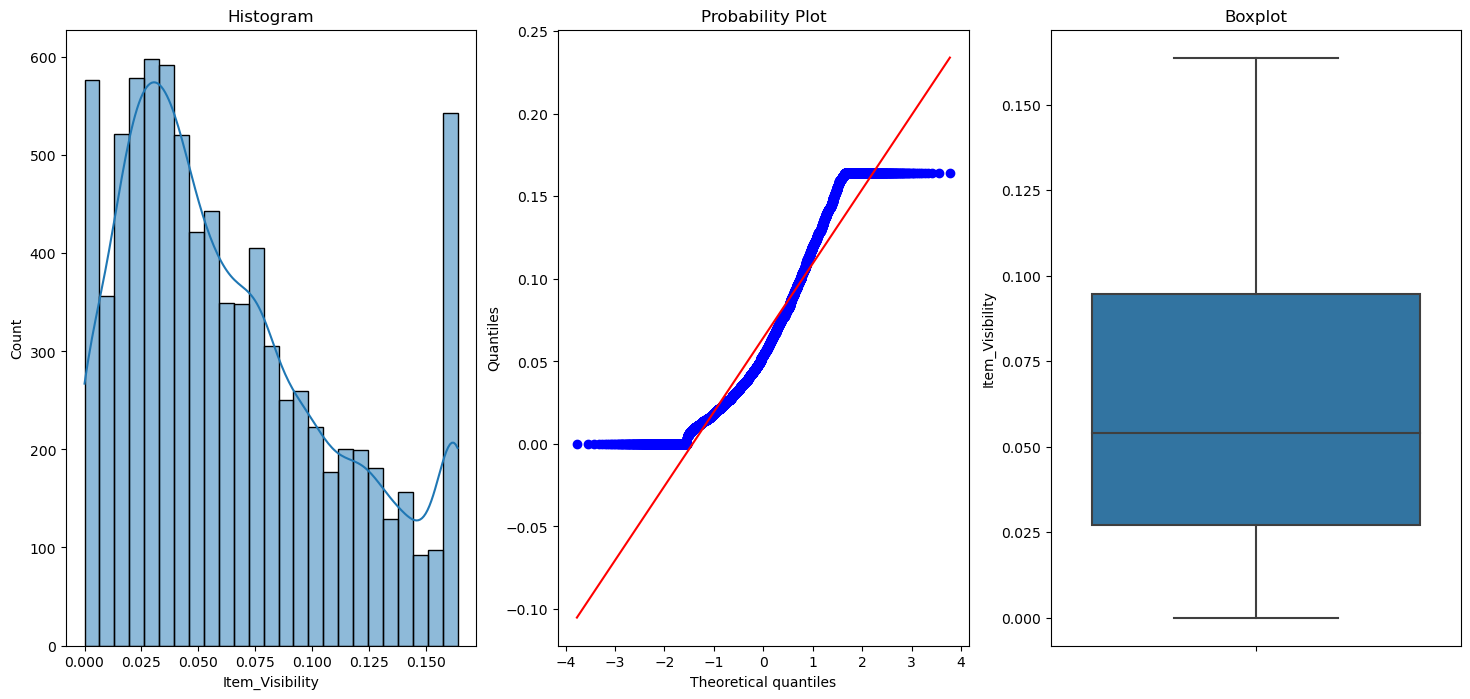

In [40]:
diagnostic_plots(supermarket_data,'Item_Visibility')

In [41]:
windsorizer.left_tail_caps_

{'Item_Visibility': 0.0}

In [42]:
windsorizer.right_tail_caps_

{'Item_Visibility': 0.1637797635999999}

### Capping

In [43]:
# windsorizer = Winsorizer(capping_method='gaussian', 
#                           tail='both',
#                           fold=3,
#                           variables=['Item_Visibility', 'Item_Outlet_Sales'])

# windsorizer.fit(supermarket_data)

In [44]:
# supermarket_data = windsorizer.transform(supermarket_data)

In [45]:
# diagnostic_plots(supermarket_data,'Item_Visibility')

In [46]:
# diagnostic_plots(supermarket_data,'Item_Outlet_Sales')

In [47]:
# windsorizer.left_tail_caps_

In [48]:
# windsorizer.right_tail_caps_

### Power transformation with Feature-engine

In [49]:
# from feature_engine.transformation import BoxCoxTransformer

In [50]:
# et = PowerTransformer(variables ['Item_Visibility','Item_MRP'], exp=0.5)

# et.fit(supermarket_data)

In [51]:
# supermarket_data = et.transform(supermarket_data)

In [52]:
# diagnostic_plots(supermarket_data,'Item_Visibility')

In [53]:
# diagnostic_plots(supermarket_data,'Item_MRP')

### Square Cube Root Transformation Method

In [54]:
# from feature_engine.transformation import PowerTransformer

In [55]:
# et = PowerTransformer(variables=['Item_Visibility','Item_MRP'], exp=1/3)

# et.fit(supermarket_data)

In [56]:
# supermarket_data = et.transform(supermarket_data)

In [57]:
# diagnostic_plots(supermarket_data,'Item_Visibility')

In [58]:
# diagnostic_plots(supermarket_data,'Item_MRP')

### YeoJohnson Transformation Method

In [59]:
yjt = YeoJohnsonTransformer(variables=['Item_Visibility','Item_MRP'])

yjt.fit(supermarket_data)

YeoJohnsonTransformer(variables=['Item_Visibility', 'Item_MRP'])

In [60]:
supermarket_data = yjt.transform(supermarket_data)

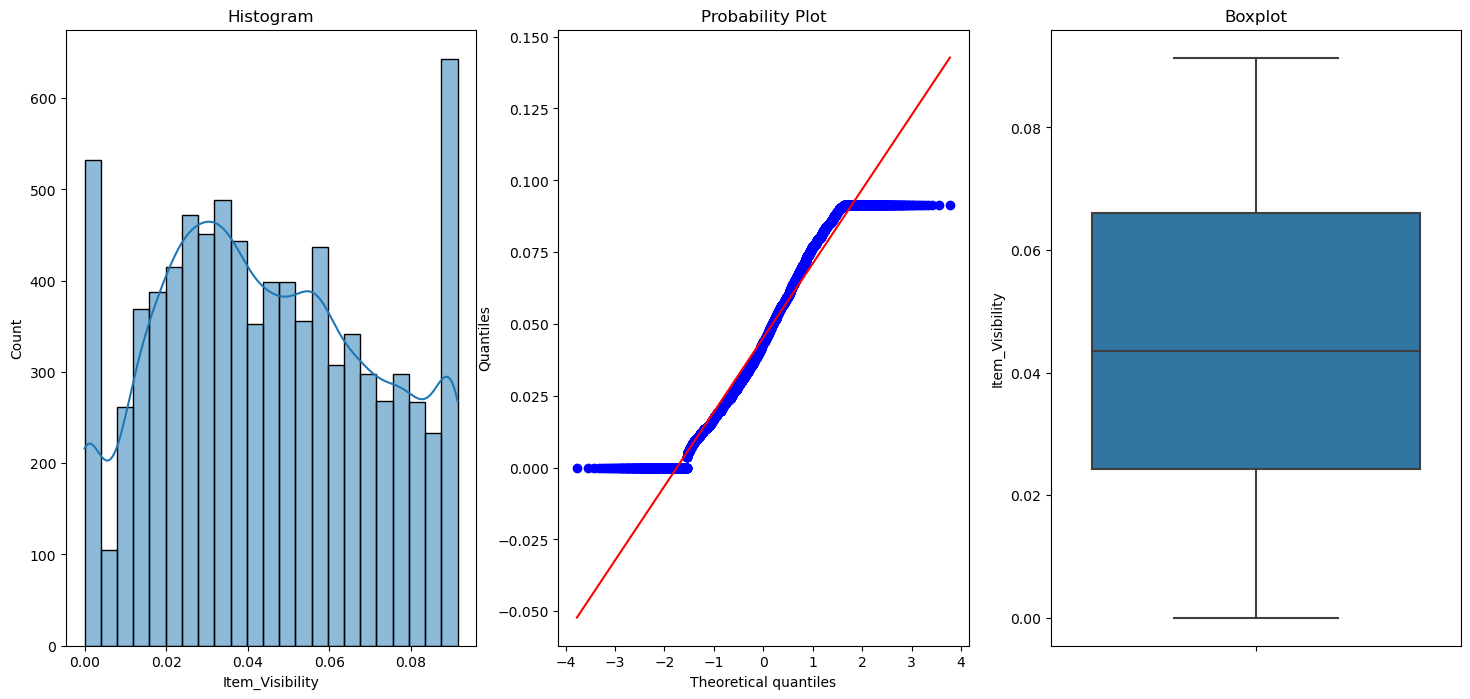

In [61]:
diagnostic_plots(supermarket_data,'Item_Visibility')

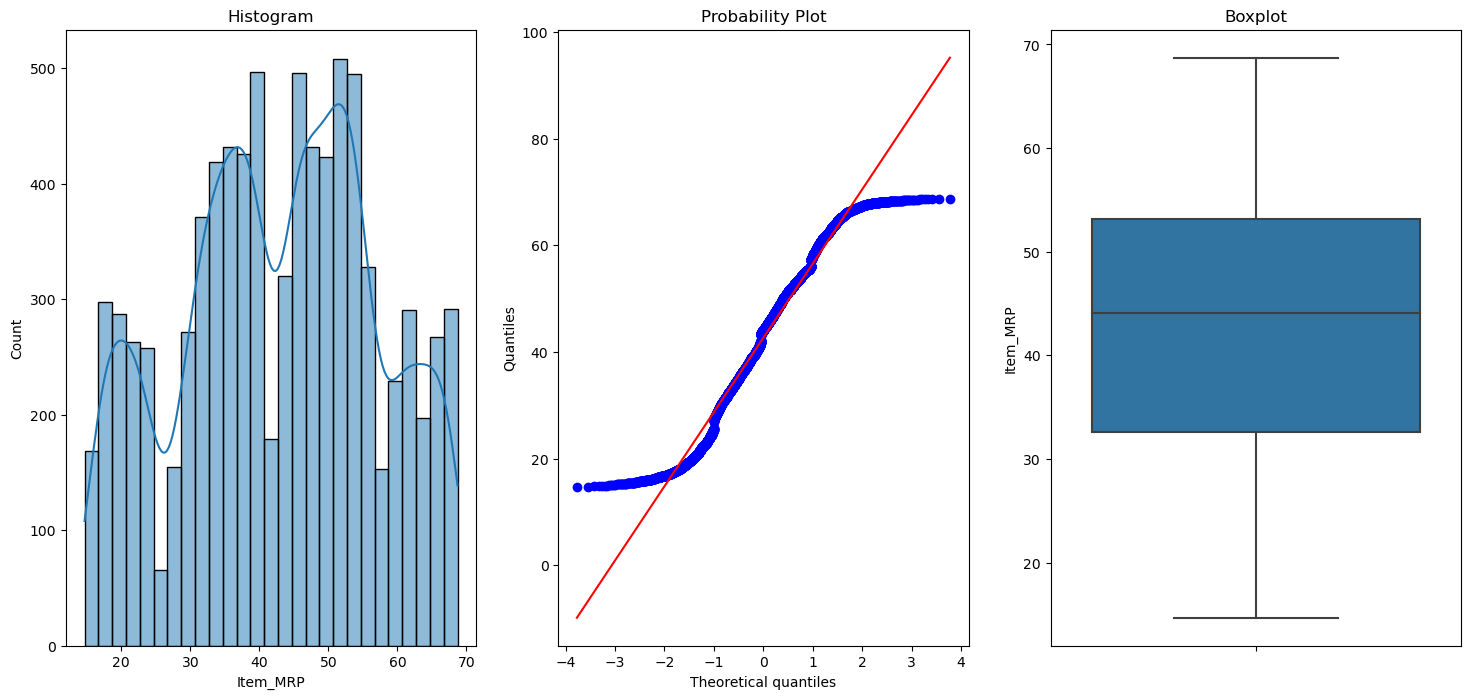

In [62]:
diagnostic_plots(supermarket_data,'Item_MRP')

In [63]:
# find numerical variables
num_cols = [c for c in supermarket_data.columns if supermarket_data[c].dtypes !='O']
supermarket_data[num_cols].isnull().mean().sort_values()

Item_Visibility              0.000000
Item_MRP                     0.000000
Outlet_Establishment_Year    0.000000
Item_Outlet_Sales            0.000000
Item_Weight                  0.171653
dtype: float64

In [64]:
supermarket_data[num_cols].describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.045237,42.672286,1997.831867,2181.288914
std,4.643456,0.026305,14.105726,8.371760,1706.499616
min,4.555000,-0.000000,14.672522,1985.000000,33.290000
25%,8.773750,0.024186,32.636732,1987.000000,834.247400
50%,12.600000,0.043571,44.125425,1999.000000,1794.331000
75%,16.850000,0.066024,53.127714,2004.000000,3101.296400
max,21.350000,0.091410,68.715025,2009.000000,13086.964800


In [65]:
# Task 3: find the categorical variables
cat_cols = [c for c in supermarket_data.columns if supermarket_data[c].dtypes=='O']
supermarket_data[cat_cols].isnull().mean().sort_values()

Item_Identifier         0.000000
Item_Fat_Content        0.000000
Item_Type               0.000000
Outlet_Identifier       0.000000
Outlet_Location_Type    0.000000
Outlet_Type             0.000000
Outlet_Size             0.282764
dtype: float64

## 1.4 Step 3: Train and Test Split <a id="part1.4"></a>

In [66]:
X_train, X_test, y_train, y_test = train_test_split(supermarket_data.drop('Item_Outlet_Sales', axis=1),
                                                    supermarket_data['Item_Outlet_Sales'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((5966, 11), (2557, 11))

In [67]:
X_train_Copy = X_train
X_test_Copy = X_test

Y_train_Copy = y_train
Y_test_Copy = y_test

## 1.5 Step 4: Missing Value Imputation <a id="part1.5"></a>

In [68]:
supermarket_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [69]:
X_train.isnull().mean()

Item_Identifier              0.000000
Item_Weight                  0.171136
Item_Fat_Content             0.000000
Item_Visibility              0.000000
Item_Type                    0.000000
Item_MRP                     0.000000
Outlet_Identifier            0.000000
Outlet_Establishment_Year    0.000000
Outlet_Size                  0.281763
Outlet_Location_Type         0.000000
Outlet_Type                  0.000000
dtype: float64

In [70]:
import feature_engine.imputation as mdi

### Mean / Median imputation with Feature-engine

In [71]:
from feature_engine.imputation import MeanMedianImputer

In [72]:
median_imputer = MeanMedianImputer(imputation_method='median',
                                   variables=['Item_Weight'])

median_imputer.fit(X_train)

MeanMedianImputer(variables=['Item_Weight'])

In [73]:
median_imputer.imputer_dict_

{'Item_Weight': 12.65}

In [74]:
X_train = median_imputer.transform(X_train)
X_test = median_imputer.transform(X_test)

In [75]:
X_train[['Item_Weight']].isnull().mean()

Item_Weight    0.0
dtype: float64

### Frequent category imputation with Feature-engine

In [76]:
import feature_engine.imputation as mdi

In [77]:
mode_imputer = mdi.CategoricalImputer(variables=['Outlet_Size'], imputation_method = 'frequent')

mode_imputer.fit(X_train)

CategoricalImputer(imputation_method='frequent', variables=['Outlet_Size'])

In [78]:
mode_imputer.imputer_dict_

{'Outlet_Size': 'Medium'}

In [79]:
X_train = mode_imputer.transform(X_train)
X_test = mode_imputer.transform(X_test)

In [80]:
X_train[['Outlet_Size']].isnull().mean()

Outlet_Size    0.0
dtype: float64

### Random Sample imputation with Feature Engine

In [81]:
# from feature_engine.imputation import RandomSampleImputer

In [82]:
# imputer = RandomSampleImputer()

# imputer.fit(X_train)

In [83]:
# X_train = imputer.transform(X_train)
# X_test = imputer.transform(X_test)

In [84]:
# X_train.isnull().mean()

## 1.6 Step 5: Categorical Data Encoding <a id="part1.6"></a>

### Ordinal Encoding

In [85]:
# # Outlet Location Type
# from feature_engine.encoding import OrdinalEncoder

# ordinal_enc = OrdinalEncoder(
#     encoding_method='arbitrary',
#     variables=['Outlet_Identifier','Item_Type'])

In [86]:
# ordinal_enc.fit(X_train)

In [87]:
# ordinal_enc.variables

In [88]:
# ordinal_enc.encoder_dict_

In [89]:
# X_train = ordinal_enc.transform(X_train)
# X_test = ordinal_enc.transform(X_test)

### Ordered Ordinal Encoding

In [90]:
from feature_engine.encoding import OrdinalEncoder

In [91]:
ordinal_enc = OrdinalEncoder(
    encoding_method='ordered',
    variables=['Item_Fat_Content'])

In [92]:
ordinal_enc.fit(X_train, y_train)

OrdinalEncoder(variables=['Item_Fat_Content'])

In [93]:
ordinal_enc.variables

['Item_Fat_Content']

In [94]:
ordinal_enc.encoder_dict_

{'Item_Fat_Content': {'Regular Fat': 0, 'Low Fat': 1, 'Regular': 2}}

In [95]:
X_train = ordinal_enc.transform(X_train)
X_test = ordinal_enc.transform(X_test)

In [96]:
X_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
88,FDN33,6.305,2,0.078085,Snack Foods,33.089440,OUT046,1997,Small,Tier 1,Supermarket Type1
6813,FDY31,5.980,1,0.036775,Fruits and Vegetables,44.964409,OUT017,2007,Medium,Tier 2,Supermarket Type1
4046,NCH54,12.650,1,0.054608,Household,47.966874,OUT027,1985,Medium,Tier 3,Supermarket Type3
8194,FDY15,12.650,2,0.091410,Dairy,47.343235,OUT019,1985,Small,Tier 1,Grocery Store
8293,NCT30,9.100,1,0.058916,Household,19.869565,OUT035,2004,Small,Tier 2,Supermarket Type1


In [97]:
X_test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4931,NCS53,14.500,1,0.063811,Health and Hygiene,47.705066,OUT045,2002,Medium,Tier 2,Supermarket Type1
4148,FDF58,12.650,1,0.009166,Snack Foods,24.921345,OUT027,1985,Medium,Tier 3,Supermarket Type3
7423,NCM29,11.500,1,0.016497,Health and Hygiene,41.145219,OUT017,2007,Medium,Tier 2,Supermarket Type1
4836,FDM40,10.195,1,-0.000000,Frozen Foods,44.147993,OUT017,2007,Medium,Tier 2,Supermarket Type1
944,FDH10,21.000,1,0.040506,Snack Foods,55.025051,OUT013,1987,High,Tier 3,Supermarket Type1


In [98]:
X_train.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content               int64
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
dtype: object

In [99]:
X_test.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content               int64
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
dtype: object

### One hot encoding

In [100]:
from feature_engine.encoding import OneHotEncoder

In [101]:
ohe_enc = OneHotEncoder(
    top_categories=None,
    drop_last=True,
    variables = ['Outlet_Size','Outlet_Location_Type','Outlet_Type']) 

In [102]:
ohe_enc.fit(X_train)

OneHotEncoder(drop_last=True,
              variables=['Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'])

In [103]:
ohe_enc.variables

['Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

In [104]:
X_train = ohe_enc.transform(X_train)
X_test = ohe_enc.transform(X_test)

### Count Frequency

In [105]:
from feature_engine.encoding import CountFrequencyEncoder

In [106]:
count_enc = CountFrequencyEncoder(
    encoding_method='count', # to do frequency ==> encoding_method='frequency'
    variables=['Outlet_Identifier','Item_Type'])

In [107]:
count_enc.fit(X_train)

CountFrequencyEncoder(variables=['Outlet_Identifier', 'Item_Type'])

In [108]:
count_enc.variables

['Outlet_Identifier', 'Item_Type']

In [109]:
count_enc.encoder_dict_

{'Outlet_Identifier': {'OUT046': 684,
  'OUT018': 660,
  'OUT017': 658,
  'OUT049': 654,
  'OUT027': 648,
  'OUT013': 637,
  'OUT045': 636,
  'OUT035': 629,
  'OUT010': 387,
  'OUT019': 373},
 'Item_Type': {'Fruits and Vegetables': 867,
  'Snack Foods': 855,
  'Household': 647,
  'Frozen Foods': 604,
  'Dairy': 473,
  'Canned': 469,
  'Baking Goods': 428,
  'Health and Hygiene': 378,
  'Meat': 299,
  'Soft Drinks': 292,
  'Breads': 174,
  'Hard Drinks': 144,
  'Others': 114,
  'Starchy Foods': 102,
  'Breakfast': 77,
  'Seafood': 43}}

In [110]:
X_train = count_enc.transform(X_train)
X_test = count_enc.transform(X_test)

## 1.7 Step 6: Variable Discretization /Binning <a id="part1.7"></a>

### Equal Width Discretization

In [111]:
from feature_engine.discretisation import EqualWidthDiscretiser

In [112]:
disc = EqualWidthDiscretiser(bins=10, variables = ['Item_Visibility','Item_Weight','Item_MRP'])

disc.fit(X_train)

EqualWidthDiscretiser(variables=['Item_Visibility', 'Item_Weight', 'Item_MRP'])

In [113]:
disc.binner_dict_

{'Item_Visibility': [-inf,
  0.009140984598455821,
  0.018281969196911642,
  0.027422953795367463,
  0.036563938393823284,
  0.0457049229922791,
  0.054845907590734926,
  0.06398689218919075,
  0.07312787678764657,
  0.08226886138610238,
  inf],
 'Item_Weight': [-inf,
  6.2345,
  7.914,
  9.5935,
  11.273,
  12.9525,
  14.632000000000001,
  16.311500000000002,
  17.991,
  19.670500000000004,
  inf],
 'Item_MRP': [-inf,
  20.263587405433093,
  25.647080467876954,
  31.030573530320815,
  36.41406659276468,
  41.79755965520854,
  47.181052717652406,
  52.56454578009627,
  57.94803884254013,
  63.33153190498399,
  inf]}

In [114]:
X_train = disc.transform(X_train)
X_test = disc.transform(X_test)

Text(0, 0.5, 'Number of observations per bin')

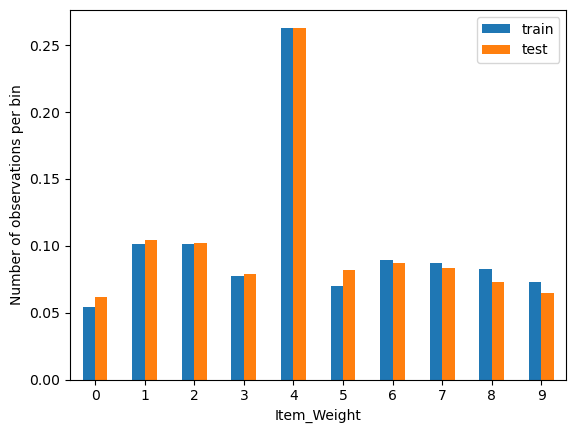

In [115]:
t1 = X_train.groupby(['Item_Weight'])['Item_Weight'].count() / len(X_train)
t2 = X_test.groupby(['Item_Weight'])['Item_Weight'].count() / len(X_test)

# concatenate aggregated views
tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']

# plot
tmp.plot.bar()
plt.xticks(rotation=0)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

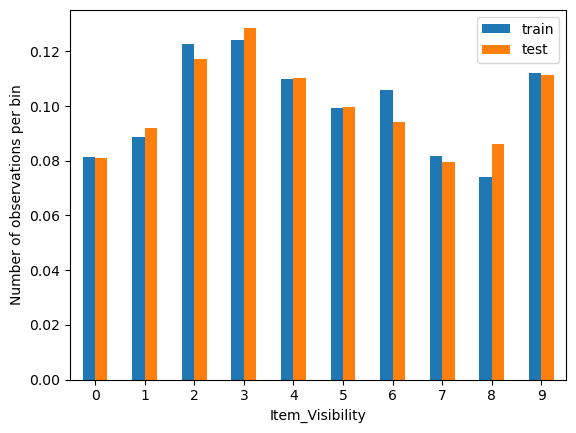

In [116]:
t1 = X_train.groupby(['Item_Visibility'])['Item_Visibility'].count() / len(X_train)
t2 = X_test.groupby(['Item_Visibility'])['Item_Visibility'].count() / len(X_test)

# concatenate aggregated views
tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']

# plot
tmp.plot.bar()
plt.xticks(rotation=0)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

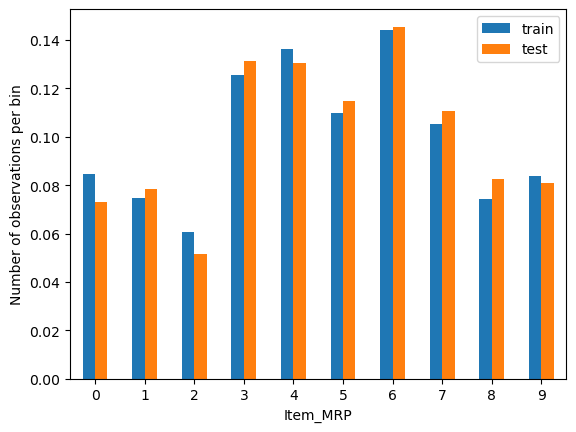

In [117]:
t1 = X_train.groupby(['Item_MRP'])['Item_MRP'].count() / len(X_train)
t2 = X_test.groupby(['Item_MRP'])['Item_MRP'].count() / len(X_test)

# concatenate aggregated views
tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']

# plot
tmp.plot.bar()
plt.xticks(rotation=0)
plt.ylabel('Number of observations per bin')

### Equal frequency discretion

In [118]:
# from feature_engine.discretisation import EqualFrequencyDiscretiser

In [119]:
# disc = EqualFrequencyDiscretiser(q=10, variables = ['Outlet_Establishment_Year'])

# disc.fit(X_train)

In [120]:
# disc.binner_dict_

In [121]:
# X_train = disc.transform(X_train)
# X_test = disc.transform(X_test)

In [122]:
# t1 = X_train.groupby(['Outlet_Establishment_Year'])['Outlet_Establishment_Year'].count() / len(X_train)
# t2 = X_test.groupby(['Outlet_Establishment_Year'])['Outlet_Establishment_Year'].count() / len(X_test)

# # concatenate aggregated views
# tmp = pd.concat([t1, t2], axis=1)
# tmp.columns = ['train', 'test']

# # plot
# tmp.plot.bar()
# plt.xticks(rotation=0)
# plt.ylabel('Number of observations per bin')

## 1.8 Step 7: Feature Engineer <a id="part1.8"></a>

In [123]:
X_train = X_train.drop(['Item_Identifier'], axis=1)
X_test = X_test.drop(['Item_Identifier'], axis=1)

In [124]:
print(X_train.columns)

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size_Small', 'Outlet_Size_Medium',
       'Outlet_Location_Type_Tier 1', 'Outlet_Location_Type_Tier 2',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type3',
       'Outlet_Type_Grocery Store'],
      dtype='object')


In [125]:
X_train['Outlet_Age'] = 2023 - X_train['Outlet_Establishment_Year']
X_test['Outlet_Age'] = 2023 - X_test['Outlet_Establishment_Year']

X_train['Outlet_Age'].head()

88      26
6813    16
4046    38
8194    38
8293    19
Name: Outlet_Age, dtype: int64

In [126]:
X_train_old = X_train
X_test_old = X_test

### Standardizing the features

In [127]:
# from sklearn.preprocessing import StandardScaler

In [128]:
# scaler = StandardScaler()

# # fit the scaler to the train set, it will learn the parameters
# scaler.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [129]:
# scaler.mean_

In [130]:
# scaler.scale_

In [131]:
# X_train= pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [132]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Weight'], ax=ax1, label ='Item_Weight')
# sns.kdeplot(X_train_old['Item_Fat_Content'], ax=ax1, label ='Item_Fat_Content')
# sns.kdeplot(X_train_old['Item_Visibility'], ax=ax1, label ='Item_Visibility')
# sns.kdeplot(X_train_old['Item_Type'], ax=ax1, label ='Item_Type')
# sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='Item_MRP')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Weight'], ax=ax2, label ='Item_Weight')
# sns.kdeplot(X_train['Item_Fat_Content'], ax=ax2, label ='Item_Fat_Content')
# sns.kdeplot(X_train['Item_Visibility'], ax=ax2, label ='Item_Visibility')
# sns.kdeplot(X_train['Item_Type'], ax=ax2, label ='Item_Type')
# sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
# ax2.legend()
# plt.show()

In [133]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Type'], ax=ax1, label ='AGE')
# sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='DIS')
# sns.kdeplot(X_train_old['Outlet_Identifier'], ax=ax1, label ='Outlet_Identifier')
# #sns.kdeplot(X_train['Outlet_Establishment_Year'], ax=ax1, label ='Outlet_Establishment_Year')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Type'], ax=ax2, label ='Item_Type')
# sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
# sns.kdeplot(X_train['Outlet_Identifier'], ax=ax2, label ='Outlet_Identifier')
# #sns.kdeplot(X_train_scaled['Outlet_Establishment_Year'], ax=ax2, label ='Outlet_Establishment_Year')
# ax2.legend()
# plt.show()

### Mean Normalization

In [134]:
# from sklearn.preprocessing import StandardScaler, RobustScaler

In [135]:
# X_train_old = X_train
# X_test_old = X_test

In [136]:
# means = X_train.mean(axis=0)
# means

In [137]:
# ranges = X_train.max(axis=0)-X_train.min(axis=0)
# ranges

In [138]:
# X_train = (X_train - means) / ranges
# X_test= (X_test - means) / ranges

In [139]:
# X_train_old.head()

In [140]:
# X_train

In [141]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Weight'], ax=ax1, label ='Item_Weight')
# sns.kdeplot(X_train_old['Item_Fat_Content'], ax=ax1, label ='Item_Fat_Content')
# sns.kdeplot(X_train_old['Item_Visibility'], ax=ax1, label ='Item_Visibility')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Weight'], ax=ax2, label ='Item_Weight')
# sns.kdeplot(X_train['Item_Fat_Content'], ax=ax2, label ='Item_Fat_Content')
# sns.kdeplot(X_train['Item_Visibility'], ax=ax2, label ='Item_Visibility')
# ax2.legend()
# plt.show()

In [142]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Type'], ax=ax1, label ='AGE')
# sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='DIS')
# sns.kdeplot(X_train_old['Outlet_Identifier'], ax=ax1, label ='Outlet_Identifier')
# #sns.kdeplot(X_train['Outlet_Establishment_Year'], ax=ax1, label ='Outlet_Establishment_Year')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Type'], ax=ax2, label ='Item_Type')
# sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
# sns.kdeplot(X_train['Outlet_Identifier'], ax=ax2, label ='Outlet_Identifier')
# #sns.kdeplot(X_train_scaled['Outlet_Establishment_Year'], ax=ax2, label ='Outlet_Establishment_Year')
# ax2.legend()
# plt.show()

### Min Max Scaling

In [143]:
# from sklearn.preprocessing import MinMaxScaler

In [144]:
# X_train_old = X_train
# X_test_old = X_test

In [145]:
# scaler = MinMaxScaler()

# # fit the scaler to the train set, it will learn the parameters
# scaler.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [146]:
# scaler.data_max_

In [147]:
# scaler.min_

In [148]:
# scaler.data_range_

In [149]:
# X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [150]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Weight'], ax=ax1, label ='Item_Weight')
# sns.kdeplot(X_train_old['Item_Fat_Content'], ax=ax1, label ='Item_Fat_Content')
# sns.kdeplot(X_train_old['Item_Visibility'], ax=ax1, label ='Item_Visibility')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Weight'], ax=ax2, label ='Item_Weight')
# sns.kdeplot(X_train['Item_Fat_Content'], ax=ax2, label ='Item_Fat_Content')
# sns.kdeplot(X_train['Item_Visibility'], ax=ax2, label ='Item_Visibility')
# ax2.legend()
# plt.show()

In [151]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Type'], ax=ax1, label ='AGE')
# sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='DIS')
# sns.kdeplot(X_train_old['Outlet_Identifier'], ax=ax1, label ='Outlet_Identifier')
# #sns.kdeplot(X_train['Outlet_Establishment_Year'], ax=ax1, label ='Outlet_Establishment_Year')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Type'], ax=ax2, label ='Item_Type')
# sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
# sns.kdeplot(X_train['Outlet_Identifier'], ax=ax2, label ='Outlet_Identifier')
# #sns.kdeplot(X_train_scaled['Outlet_Establishment_Year'], ax=ax2, label ='Outlet_Establishment_Year')
# ax2.legend()
# plt.show()

### Centering + MaxAbsScaling

In [152]:
# from sklearn.preprocessing import MaxAbsScaler, StandardScaler

In [153]:
# X_train_old = X_train
# X_test_old = X_test

In [154]:
# scaler = MaxAbsScaler()

# # fit the scaler to the train set, it will learn the parameters
# scaler.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [155]:
# scaler.max_abs_

In [156]:
# # set up the StandardScaler so that it removes the mean
# # but does not divide by the standard deviation
# scaler_mean = StandardScaler(with_mean=True, with_std=False)

# # set up the MaxAbsScaler normally
# scaler_maxabs = MaxAbsScaler()

# # fit the scalers to the train set, it will learn the parameters
# scaler_mean.fit(X_train)
# scaler_maxabs.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler_maxabs.transform(scaler_mean.transform(X_train))
# X_test_scaled = scaler_maxabs.transform(scaler_mean.transform(X_test))

In [157]:
# X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [158]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Weight'], ax=ax1, label ='Item_Weight')
# sns.kdeplot(X_train_old['Item_Fat_Content'], ax=ax1, label ='Item_Fat_Content')
# sns.kdeplot(X_train_old['Item_Visibility'], ax=ax1, label ='Item_Visibility')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Weight'], ax=ax2, label ='Item_Weight')
# sns.kdeplot(X_train['Item_Fat_Content'], ax=ax2, label ='Item_Fat_Content')
# sns.kdeplot(X_train['Item_Visibility'], ax=ax2, label ='Item_Visibility')
# ax2.legend()
# plt.show()

In [159]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Type'], ax=ax1, label ='AGE')
# sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='DIS')
# sns.kdeplot(X_train_old['Outlet_Identifier'], ax=ax1, label ='Outlet_Identifier')
# #sns.kdeplot(X_train['Outlet_Establishment_Year'], ax=ax1, label ='Outlet_Establishment_Year')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Type'], ax=ax2, label ='Item_Type')
# sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
# sns.kdeplot(X_train['Outlet_Identifier'], ax=ax2, label ='Outlet_Identifier')
# #sns.kdeplot(X_train_scaled['Outlet_Establishment_Year'], ax=ax2, label ='Outlet_Establishment_Year')
# ax2.legend()
# plt.show()

### Scaling to quantiles and median - RobustScaling

In [160]:
from sklearn.preprocessing import RobustScaler

In [161]:
scaler = RobustScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [162]:
scaler.center_

array([4.000e+00, 1.000e+00, 4.000e+00, 4.730e+02, 5.000e+00, 6.480e+02,
       1.999e+03, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
       0.000e+00, 0.000e+00, 2.400e+01])

In [163]:
scaler.scale_

array([  4.,   1.,   5., 477.,   4.,  22.,  17.,   1.,   1.,   1.,   1.,
         1.,   1.,   1.,  17.])

In [164]:
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

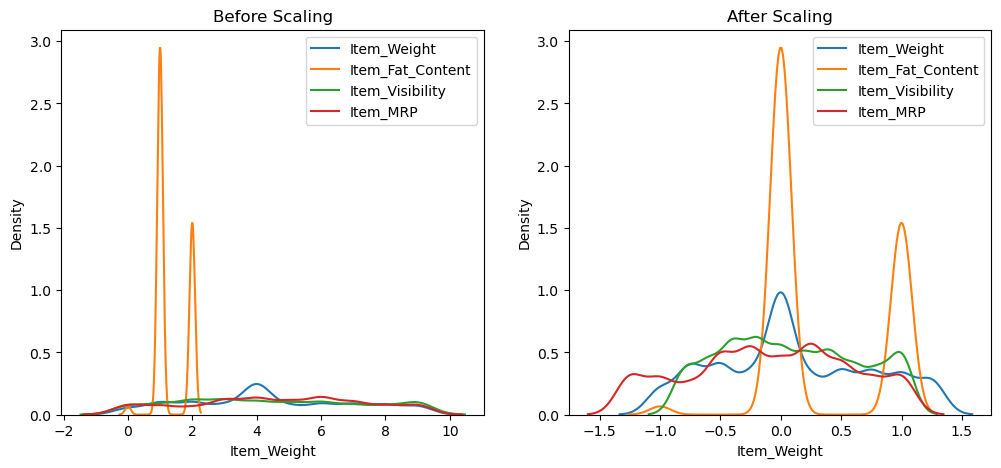

In [165]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train_old['Item_Weight'], ax=ax1, label ='Item_Weight')
sns.kdeplot(X_train_old['Item_Fat_Content'], ax=ax1, label ='Item_Fat_Content')
sns.kdeplot(X_train_old['Item_Visibility'], ax=ax1, label ='Item_Visibility')
sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='Item_MRP')
ax1.legend()

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train['Item_Weight'], ax=ax2, label ='Item_Weight')
sns.kdeplot(X_train['Item_Fat_Content'], ax=ax2, label ='Item_Fat_Content')
sns.kdeplot(X_train['Item_Visibility'], ax=ax2, label ='Item_Visibility')
sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
ax2.legend()
plt.show()

In [166]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# # before scaling
# ax1.set_title('Before Scaling')
# sns.kdeplot(X_train_old['Item_Type'], ax=ax1, label ='Item_Type')
# sns.kdeplot(X_train_old['Item_MRP'], ax=ax1, label ='Item_MRP')
# ax1.legend()

# # after scaling
# ax2.set_title('After Scaling')
# sns.kdeplot(X_train['Item_Type'], ax=ax2, label ='Item_Type')
# sns.kdeplot(X_train['Item_MRP'], ax=ax2, label = 'Item_MRP')
# ax2.legend()
# plt.show()

### Polynomial Expansion

In [167]:
from sklearn.preprocessing import PolynomialFeatures

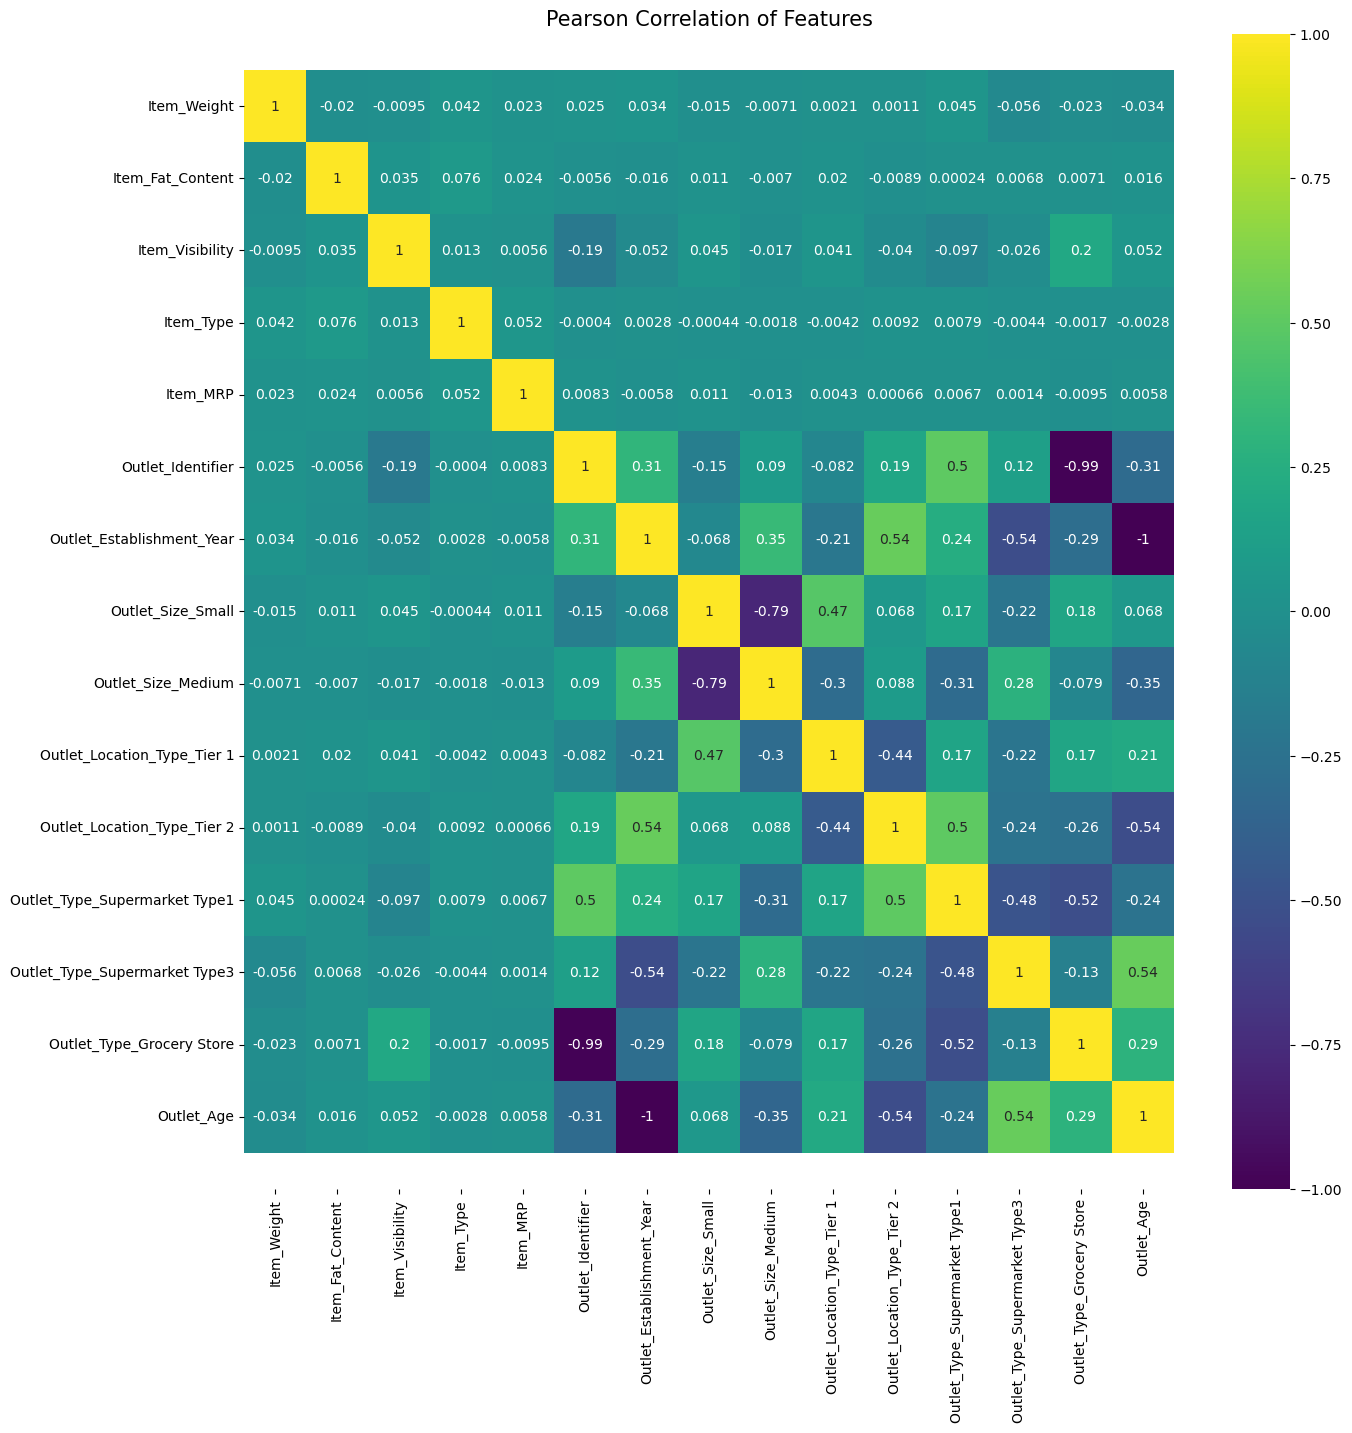

In [168]:
colormap = plt.cm.viridis
plt.figure(figsize=(15,15))
plt.title('Pearson Correlation of Features', size=15)
ax = sns.heatmap(X_train.astype(float).corr(), cmap=colormap, annot=True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

In [169]:
poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)

In [170]:
poly.fit(X_train)

PolynomialFeatures(degree=3, include_bias=False)

In [171]:
X_train = poly.transform(X_train)
X_test = poly.transform(X_test)

In [172]:
# for f in ['Outlet_Location_Type', 'Outlet_Size']:
#     plt.scatter(X_train[f], y_train)
#     plt.title(f)
#     plt.show()

### PCA

In [173]:
# from sklearn.decomposition import PCA

In [174]:
# pca = PCA()

In [175]:
# pca.fit(X_train_scaled)

In [176]:
# X_train = pca.transform(X_train_scaled)
# X_test = pca.transform(X_test_scaled)

In [177]:
# print(len(pca.explained_variance_ratio_))
# print(pca.explained_variance_ratio_)

In [178]:
# plt.plot(pca.explained_variance_ratio_, linewidth=2)
# plt.title('Percentage of Variance Explained')
# plt.xlabel('Index Number of Components')
# plt.ylabel('Percentage of Variance Explained')

In [179]:
# X_train_scaled

In [180]:
# X_train

## 1.9 Step 8: Linear Regression Modelling <a id="part1.9"></a>

Linear regression is defined as a machine learning model in which the model finds the best fit linear line between the independent and dependent variables in which the aim is to find the best fit linear line and the optimal values of intercept and coefficients such that errors are minimized. For the purpose of this analysis, the goal is to use the X variables e.g. columns other than item outlet sales,to predict the item outlet sales (y variable, or target variable).
### Building and Evaluating the Model
In order to evaluate the model performance of a linear regression model, a range of measures can be used, but in this ASG1 we will focus on only 2:

- Mean Square Error (MSE): The MSE is the variance of the residuals, that is, the squared differences between prediction and actual observation. Lower values of MSE indicate better fit and model performance.
- R-Square: R-square represents the percentage of the response variable variation that is explained by a linear model. The closer to 1.0 the value of R-square, the more indicative of a better fit and model performance.

In [181]:
# assign your fully cleaned and transformed data contained within your versions of 
# X_train_student_final_premodel_version, X_test_student_final_premodel_version,
# y_train_student_final_premodel_version and y_test_student_final_premodel_version into
# the prepared variables below, for a simple linear regression model

In [182]:
X_train_final = X_train#_student_final_premodel_version
X_test_final = X_test#_student_final_premodel_version

y_train_final = y_train#_student_final_premodel_version
y_test_final = y_test#_student_final_premodel_version

In [183]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [184]:
# Build Linear Regression Model
model_linear_regression = LinearRegression()
model_linear_regression.fit(X_train_final, y_train_final)

# Evaluate the Linear Regression Model using Mean Square Error (MSE)
# The lower MSE, the better the model performance
print('train_mse:', mean_squared_error(y_train_final, model_linear_regression.predict(X_train_final)), 
      '\n test_mse:', mean_squared_error(y_test_final, model_linear_regression.predict(X_test_final)))

# Evaluate the Linear Regression Model using R-Square
# The closer the r-square value to 1, the better the model performance
print('train_r-sq:', r2_score(y_train_final, model_linear_regression.predict(X_train_final)), 
      '\n test_r-sq:', r2_score(y_test_final, model_linear_regression.predict(X_test_final)))

train_mse: 1092226.3665702296 
 test_mse: 1227246.2856968835
train_r-sq: 0.6173050310407344 
 test_r-sq: 0.5969743400457556


In [185]:
# y_train_pred = model_linear_regression.predict(X_train_final)
# y_test_pred = model_linear_regression.predict(X_test_final)

# plt.scatter(y_train_final, y_train_pred, color='blue', label='Training data')
# plt.scatter(y_test_final, y_test_pred, color='red', label='Test data')
# plt.plot([y_train_final.min(), y_train_final.max()], [y_train_final.min(), y_train_final.max()], color='black', linestyle='--')
# plt.xlabel('Actual values')
# plt.ylabel('Predicted values')
# plt.legend(loc='upper left')

# plt.show()

In [186]:
# train_mse: 1258065.8541578895 
#  test_mse: 1344055.697334858
# train_r-sq: 0.5591980859082217 
#  test_r-sq: 0.5586143215531926

# 2. Report <a id="part2"></a>

## 2.1 Introduction <a id="part2.1"></a>

To predict the sales of each product at a particular outlet using the data collected at various supermarket outlets and stores in different cities, we have to look at the data given and identify possible trends and relationships that can be formed to be able to accurately make sales predictions and find ways to increase sales for particular products and outlets. To help transform the data to give accurate predictions, the following parts would be implemented. Part 1, investigates the relationship between different features and variables. Part 2, data cleansing to fill in the missing values and due with outliers. Part 3, Data transformation on categorical and numerical data. Part 4, includes feature scaling and implementing new features, and dropping features. Part 5. Building and evaluating the linear regression model. After implementing Part 1 to Part 5, we should be able to make accurate predictions for the supermarket management team to try to understand the properties of products and outlets to increase sales.   (159 words)

## 2.2 Data Exploration <a id="part2.2"></a>

To increase sales we can look at the different outlet types to see any potential trends and relationships that can be formed.

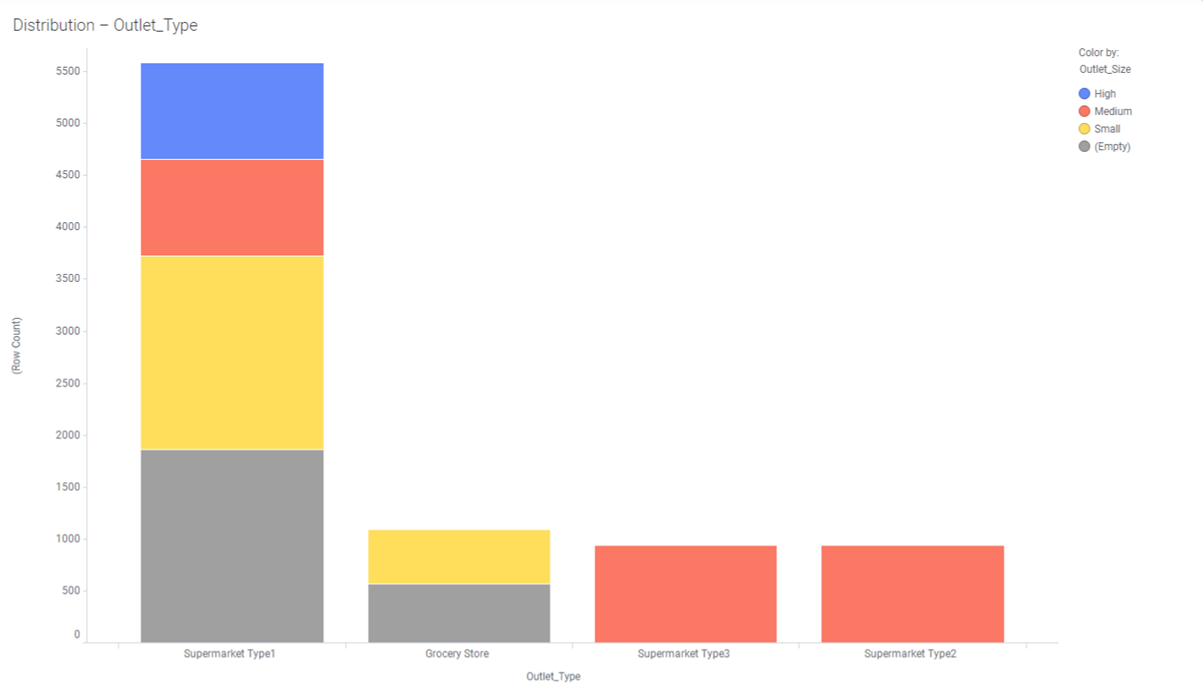

In [187]:
Image(filename="./outlet size by outlet type.png")

This visual shows the breakdown of the outlet size for each outlet type. The visuals shows that there are 3 different outlet types: supermarket type1, supermarket type3, supermarket type2, and grocery store. Supermarket type1 has the most number of outlets and supermarket type2 &3  has the least. It also shows that this data set contains null values and supermarket type1 has all all 3 tiers of outlet sizes as well as null values, grocery store has small outlet size and null values. Both supermarket type 3 and 2 have only medium outlet size.

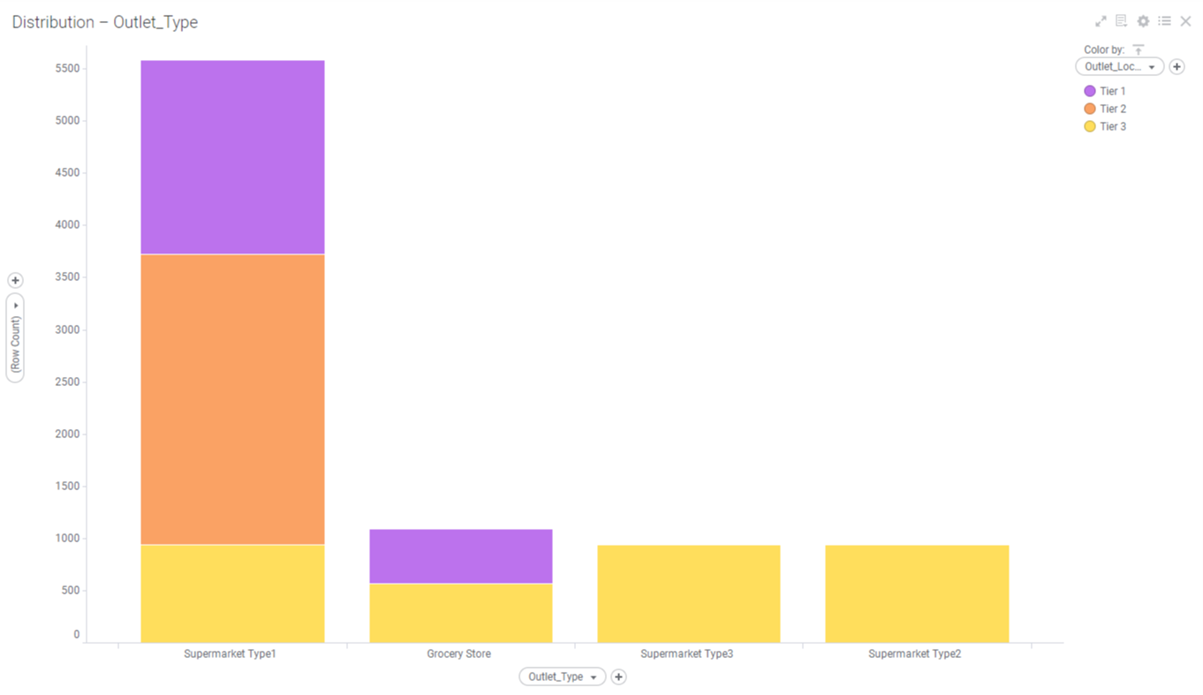

In [188]:
Image(filename="./outlet location by outlet type.png")

This visual shows the breakdown of the outlet locations tier for each outlet type. From this visual, it shows that for the 4 different outlet types, Supermarket Type 1 has all 3 tiers of outlet location type while Grocery store has Tier 1 and 3 and Supermarket Type 3 and 2 only have tier 3 outlet location types with no null values.

The 2 visuals above shows they different supermarket types, but with a different variant- by Tiers and by Outlet types. With these 2 visuals, we can compare and analyse the chart- comparing the different relationships by outlet type, outlet size and outlet location type. The charts showed us that Supermarket Type 3 & Type 2 are both in Medium size and in Tier 3. The Grocery Store has 2 types of outlet sizes and 2 types of Tiers. Supermarket Type 1 has 4 different type of outlet sizes and 3 types of Tiers. Meaning that when filtering supermarket data for tier 1 I would not be looking at supermarket types 3 and 2.

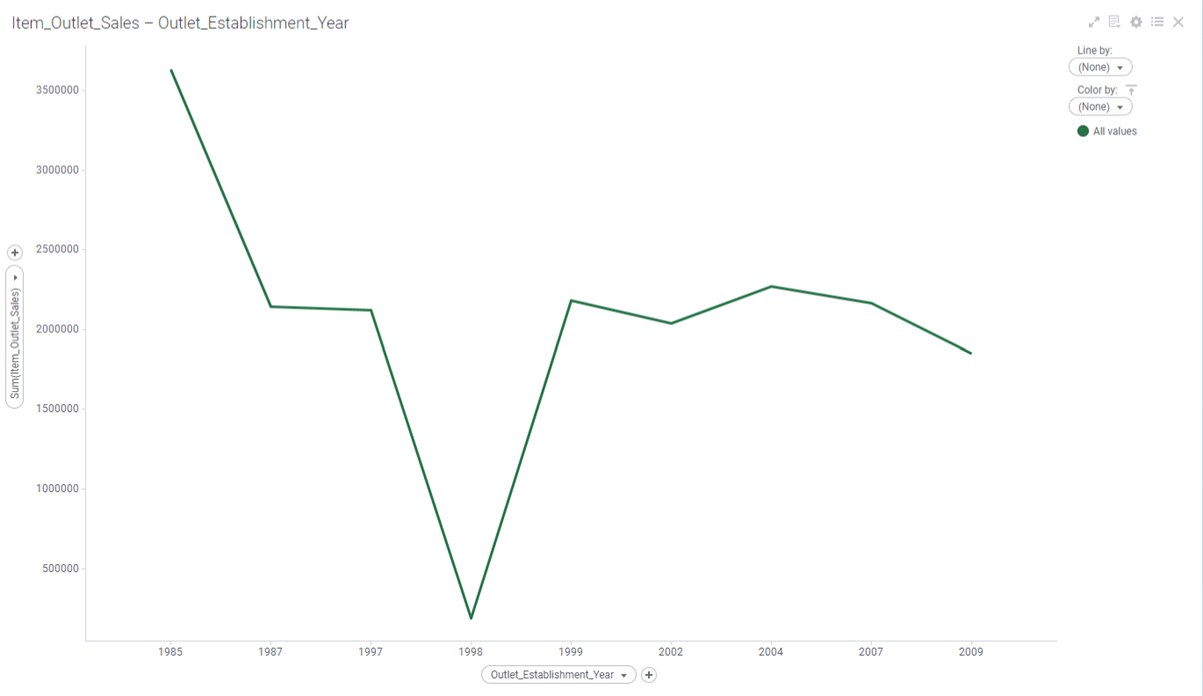

In [189]:
Image(filename="./item outlet sales by establishment year.png")

This visual shows the breakdown of item outlet sales by establishment year. This visual shows that the outlets that are established in the year 1985 has the highest sales and outlets that are established in the year 1998 has the lowest sales. while the other years do not show such drastic changes. With this data, we can look at why outlets established in the year 1998 received such bad sales and see how we can prevent that from occurring again and what was done for outlets established in the year 1995 to have such a drastic height in sales. (391 words)

## 2.3 Data Cleansing <a id="part2.3"></a>

The data given comprises data collected from supermarket stores and outlets in various cities. It contains 12 different columns with information on supermarkets, 7 of the columns contain categorical data and 5 contain numerical data.
Within the dataset, columns named Item_Weight and Outlet_Size contains null values 1463 and 2410 respectively. The dataset also contains variable inconsistencies in naming conventions for column named Item_Fat_Content. Columns named Item_Visibility and Item_Outlet_Sales contain outliers.
To clean my data, I standardized the naming consistencies of the variables in column named Item_Fat_Content ensuring that all values representing the fat content of items in the dataset follow a consistent naming scheme. By standardizing the naming conventions, I eliminated any potential discrepancies or duplicates in the data. Next, I applied winsorization which replaces extreme values (outliers) with values closer to the mean or a specified percentile. On column named Item_Visibility only, as column named Item_Outlet_Sales is my target variable to remove outliers by winsorizing column named Item_Visibility, mitigating the impact of outliers on the statistical analysis and modeling. 
After splitting my data into train and test sets splitting the data into train data (70%) and test data (30%) with column named Item_Outlet_Sales as my target variable. To deal with my missing data in column named Item_Weight and Outlet_Size, I used Mean / Median imputation for column named Item_Weight as this can only be performed in numerical variables. Mean or median imputation consists of replacing missing values with the variable mean or median. The mean or the median is calculated using the train set. For column named Outlet_Size I used Frequent category imputation to deal with the missing value. Frequent category imputation consists of replacing missing values with the mode. We normally use this procedure in categorical variables. Frequent categories are estimated using the train set.
Besides these methods, I also tried methods like Capping for my outliers and Random Sample imputation to try and see how different methods would affect my R-Square value.
By performing these data cleaning steps, the dataset was prepared for further analysis and modeling, ensuring consistency in naming conventions, handling outliers, and addressing missing values appropriately for numerical and categorical variables.


## 2.4 Data Transformation <a id="part2.4"></a>

To transform my data, I encoded my categorical data to transform those objects into strings. First, I used ordered ordinal encoding- a technique used to encode categorical variables when there is a natural ordering or hierarchy among the categories for Column "Item_Fat_Content". I applied ordered ordinal encoding to create a monotonic relationship between the categories and the response variable, making the variables more adequate for use in linear models. The categories are ordered from the one with the lowest mean target value to the one with the highest mean target value. 
Next, I used one hot encoding for columns "Outlet_Size", "Outlet_Location_Type", and "Outlet_Type". One-hot encoding creates new binary (0 or 1) columns for each distinct category in the original categorical column. Each binary column represents a specific category, and a value of 1 indicates the presence of that category for a particular observation, while a value of 0 indicates the absence. By using one-hot encoding, I transformed these categorical columns into a format that is suitable for various machine learning algorithms.
Lastly, for column "Outlet_Identifier" and "Item_Type", I used Count frequency to encode them. Count frequency encoding is a technique that replaces each category with its corresponding frequency count in the dataset. For column "Outlet_Identifier" and "Item_Type", each category was replaced with the number of occurrences or frequency of that category in the dataset. By encoding the categories based on their frequency, it captures the relative importance or prevalence of each category within the dataset.
Next, I used the YeoJohnson Method. This is a data transformation technique that addresses skewness and makes the data more normally distributed. By applying the YeoJohnson transformation to the columns "Item_Visibility" and "Item_MRP", I aimed to make the distribution of these variables more symmetric and closer to a normal distribution. This transformation can improve the performance of certain statistical analyses and models that assume normality. As column "Item_Weight" contains null values, I was unable to conduct winsorization on the column. 
Next, for the columns "Item_Visibility", "Item_Weight", and "Item_MRP", I used equal width discretion to Bin them. Equal width discretization, also known as binning, is a technique used to divide continuous variables into a specified number of bins of equal width. By applying equal width discretization to these columns, continuous variables can be converted into categorical variables represented by their corresponding bins.
While performing data transformations, I attempted other methods of encoding like ordinal encoding for columns "Outler_Identifier", and "Item_Type", as well as power transformation and Square Cube Root Transformation for columns "Item_Visibility", and "Item_MRP". Lastly, I also tried Equal frequency discretion for binning before deciding on the methods mentioned above as the more suitable option to produce a better train model.
By applying these transformation techniques, the categorical and numerical variables were prepared for further analysis and modelling, allowing for a more comprehensive understanding of the relationships within the dataset and improving the performance of the linear regression model.


## 2.5 Feature Engineering <a id="part2.5"></a>

For feature engineering, I decided to drop column "Item_identifier". This decision was made due to the high cardinality of the column. High cardinality refers to a large number of unique values within a feature, which can lead to overfitting and negatively impact the model's performance. By removing this column, the risk of overfitting can be mitigated and improve the generalization ability of the model.
In addition to dropping column "Item_Identifier", I implemented a new feature called outlet_age to gain insights into the relationship between the outlet age and other supermarket data. This feature was created by subtracting the establishment year of each outlet from the current year. By calculating the outlet age, it aims to identify any trends or patterns that could potentially be leveraged to implement effective sales strategies based on the relationship between the outlet age, item type, and sales. We will be able to identify if the age of the outlet has an impact on the type of products sold. For example, older supermarkets may have customers who only shop there due to familiarity with the surroundings or particular products purchased unavailable elsewhere. With this data, we can identify the bahviour of returning customers and try to replicate that in other stores. Newer stores may have more new technology implemented in the outlet which may attract customers. To increase customer experience in supermarket outlets in older stores, we can implement the new technologies in the newer outlets to the older stores to increase sales.
After creating the outlet_age feature, I applied Robust Scaling to the input features. Robust Scaling is a technique that accounts for the presence of outliers and variations in the data by subtracting the median and dividing by the interquartile range. This scaling method helps ensure that the features are brought to a similar scale. This pre-processing step is essential for many machine learning algorithms as it helps to avoid the dominance of features with larger magnitudes and ensures a fair comparison between different features.
Following the scaling step, I proceed to perform polynomial expansion on my train and test sets. Polynomial expansion is a technique that generates additional features by taking combinations of existing features and their powers. By including higher-order terms, polynomial expansion can capture more complex relationships between the features and the target variable.
To try and find the best method to increase my R-Square value I have also tried standardizing the features Mean normalization, Min Max Scaing, Centering + MaxAbsScaling, and PCA but deciding on the methods mentioned above as the more suitable option to produce a better train model.
By implementing these feature engineering techniques, I have improved the model's performance and uncovered hidden patterns in the data. The combination of dropping column "Item_Identifier", creating the outlet_age feature, scaling the input features using Robust Scaling, and conducting polynomial expansion allowed for a more comprehensive analysis and a better understanding of the relationships within the dataset.


## 2.6 Linear Regression Model <a id="part2.6"></a>

A linear regression model is a machine learning model where the model finds the best fit linear line between the independent and dependent variables and values such that the capacity for inaccuracies is reduced. With this model, I can derive two values; the Mean Square Error (MSE) which measures the average squared difference between the predicted values and the actual values in the dataset providing a measure of how well the model's predictions match the true values. It quantifies the average magnitude of the errors made by the model. A lower MSE indicates a better fit of the model to the data, as it means that the predicted values are closer to the actual values. Conversely, a higher MSE indicates larger prediction errors and poorer model performance. R-Square is a statistical measure that represents the proportion of the variance in the dependent variable that can be explained by the independent variables in a regression model to provide an indication of how well my regression model fits the data. R-squared tells you how much of the variability in the dependent variable can be attributed to the independent variables used in the regression model from 0 indicating that the regression model does not explain any of the variability in the dependent variable to 1 which indicates that the regression model explains all of the variability in the dependent variable. A higher R-squared value indicates a better fit of the model to the data. 
My mean square error values are 1092226.3665702296 for my train set and 1227246.2856968835 for my test set. Both values have decreased from before I performed feature engineering on them where the values were, 1258065.8541578895 for my train set and 1344055.697334858 for my test set indicating an improvement in the model's performance. The lower MSE values indicate that the model's predictions are closer to the actual values, reflecting a better fit to the data.
Similarly, the R-squared values for both the train and test sets increased after feature engineering. My R-Square values are 0.6173050310407344 for my train set and 0.5969743400457556 for my test set which has increased to be closer to 1 from 0.5591980859082217 for my train set and 0.5586143215531926 for my test set before feature engineering. This indicates that a larger proportion of the variability in the dependent variable can be explained by the independent variables. The R-squared values being closer to 1 suggest that the model's fit to the data has improved.
By creating a linear regression model, and observing the improvements in the mean square error and R-squared values, I can see how data cleansing, transformation, and feature engineering steps are done to enhance the reliability and performance of the linear regression model. These steps have helped create a more robust and accurate model that can be utilized for analyzing and making predictions based on the provided dataset.
 


## 2.7 Summary and Further Improvements <a id="part2.7"></a>

In summary, 
Feature scaling and engineering were performed to enhance the model's performance to enhance accuracy in sales predictions of each product at specific outlets using the provided dataset. Several steps were undertaken to receive high MSE and low R-Square values. The process began with exploring the data to identify trends and relationships between different features and variables. Subsequently, data cleansing techniques were applied to handle missing values and outliers, ensuring data integrity. Categorical and numerical data were then transformed using encoding and discretization methods to make them suitable for analysis. The inclusion of a new feature "outlet_age" provided insights into the relationship between the outlet's age and other supermarket data. Robust scaling helped to standardize the input features, and polynomial expansion allowed for capturing more complex relationships in the data.
The linear regression model was built and evaluated to predict sales accurately. The Mean Square Error (MSE) and R-square values obtained showed improvements in the values from data cleansing, transformation, and feature engineering.
Further improvements to enhance the model's performance are Feature Selection, implementing feature selection techniques can help identify the most relevant features for the sales prediction task. This involves assessing the importance of each feature in relation to the target variable. By selecting the most informative features, we can focus on the factors that have the greatest impact on sales. Techniques like recursive feature elimination or Lasso regression can assist in identifying the optimal subset of features. Similarly, adding polynomial features, such as squared or cubed terms, can account for non-linear relationships that might exist in the data. These techniques can help the model capture more nuanced patterns and improve its predictive capabilities. Incorporating External Data consider incorporating external data sources that could provide additional insights into sales patterns. This could include factors like economic indicators, or demographic information about the locations of the outlets. By integrating such data, the model can account for external factors that influence sales, leading to more accurate predictions. Lastly, having additional data on customers to help use that data to find trends and relationships to understand what drives customer's purchase patterns to increase sales.
By implementing these improvements, further enhancement to the model's performance can be made to improve its ability to capture complex relationships and make more accurate sales predictions. These steps will enable the supermarket management team to gain deeper insights into the factors affecting sales and devise more effective strategies to increase sales and optimize their operations.
Overall, the combination of data exploration, cleansing, transformation, feature engineering, and the utilization of a linear regression model has resulted in a reliable and accurate tool for sales predictions. By implementing further improvements, the model's performance can be enhanced, enabling the supermarket management team to understand product and outlet properties better and devise effective strategies to increase sales.
